📓 Feature Engineering Notebook

In [166]:
# ---
# 🧪 Imports
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
from math import radians, cos, sin, asin, sqrt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
# ---
# 📥 Load Cleaned Data
df = pd.read_csv("../data/processed/AB_NYC_2019_quality_assessed.csv")
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
1,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
2,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
3,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129
4,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,0.40,1,0


In [167]:
#---------------------------------------------------
#Step 1: Quick Overview of Data
#---------------------------------------------------

# Print dataset shape: rows × columns
print("Dataset shape (colums, rows):", df.shape)

# Print summary of column names, types, null counts, etc.
df.info()

# Show basic stats (mean, min, max, std) for numeric columns
df.describe()

# ---
# 🧠 Why this matters:
# This gives a quick overview of the data:
#  Are there missing values?
#  What kind of columns are there (numeric, text)?
#  Do the values look reasonable?

Dataset shape (colums, rows): (33842, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33842 entries, 0 to 33841
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             33842 non-null  object 
 1   neighbourhood                   33842 non-null  object 
 2   latitude                        33842 non-null  float64
 3   longitude                       33842 non-null  float64
 4   room_type                       33842 non-null  object 
 5   price                           33842 non-null  int64  
 6   minimum_nights                  33842 non-null  int64  
 7   number_of_reviews               33842 non-null  int64  
 8   reviews_per_month               33842 non-null  float64
 9   calculated_host_listings_count  33842 non-null  int64  
 10  availability_365                33842 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 2.

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,33842.000000,33842.000000,33842.000000,33842.000000,33842.000000,33842.000000,33842.000000,33842.000000
mean,40.727766,-73.949127,108.379558,6.011081,30.012942,1.379930,4.639856,108.563619
std,0.056330,0.046789,55.815809,17.951016,49.072691,1.697543,23.210948,127.338025
min,40.506410,-74.244420,0.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,40.687570,-73.980328,65.000000,1.000000,3.000000,0.190000,1.000000,0.000000
50%,40.720080,-73.952980,95.000000,2.000000,10.000000,0.710000,1.000000,44.000000
75%,40.763830,-73.932255,149.000000,4.000000,34.000000,2.030000,2.000000,212.000000
max,40.913060,-73.712990,250.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [168]:
# -------------------------------------------------------------------------------------
# Step 2: Feature Engineering (Human-Readable) 
#--------------------------------------------------------------------------------------

# Feature 1:combine number of reviews and reviews per month into a new feature: total_reviews with lo
df['total_reviews'] = df['number_of_reviews'].fillna(0)

#No negative
df['total_reviews'] = df['number_of_reviews'].clip(lower=0)

#Convert to integer
df['total_reviews'] = df['number_of_reviews'].astype(int)

#Create the activity flash from total reviews
df['has_reviews'] = (df['total_reviews'] > 0 ).astype(int)

#Transformed version for modelling
df['log_total_reviews'] = np.log1p(df['total_reviews'])  # Log-transform to handle skewness

# Feature 2: comnbine latitude and longitude into a new feature: location_score which will be derived by the Haversine formula to calculate distance from neighbourhoods to various points of interest (POI)

# POI Coordinates
pois = {
    'times_square': (40.7580, -73.9855),
    'wall_street': (40.7061, -74.0091),
    'central_park': (40.7812, -73.9665)
}

# Vectorized Haversine for efficiency with large DataFrames
def haversine_vec(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

# Apply to your DataFrame
for name, coords in pois.items():
    df[f'dist_km_{name}'] = haversine_vec(df['latitude'], df['longitude'], coords[0], coords[1])

# 📊 Quick Look at Engineered Data
df.head()
# ---


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,total_reviews,has_reviews,log_total_reviews,dist_km_times_square,dist_km_wall_street,dist_km_central_park
0,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,45,1,3.828641,0.508366,5.698776,3.394152
1,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,270,1,5.602119,8.387034,4.768098,10.696471
2,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,9,1,2.302585,5.701496,11.647582,2.701110
3,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129,74,1,4.317488,1.449704,5.442729,3.796468
4,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,0.40,1,0,49,1,3.912023,8.290747,4.963633,10.525438


In [169]:
#------------------------------------------------------------------------------------------------------
# Step 3: Quick Look at Engineered Data
#------------------------------------------------------------------------------------------------------
df[['log_total_reviews', 'dist_km_times_square', 'dist_km_wall_street', 'dist_km_central_park', 'has_reviews']].describe()

,log_total_reviews,dist_km_times_square,dist_km_wall_street,dist_km_central_park,has_reviews
count,33842.000000,33842.000000,33842.000000,33842.000000,33842.0
mean,2.526250,7.500368,8.060114,8.364743,1.0
std,1.344251,4.382795,4.601080,4.716239,0.0
min,0.693147,0.072397,0.010284,0.464528,1.0
25%,1.386294,4.273653,4.839276,4.751953,1.0
50%,2.397895,7.227604,6.980441,7.801475,1.0
75%,3.555348,9.688099,10.596821,11.197700,1.0
max,6.445720,35.232419,29.544209,38.249486,1.0


In [170]:
df.shape

(33842, 17)

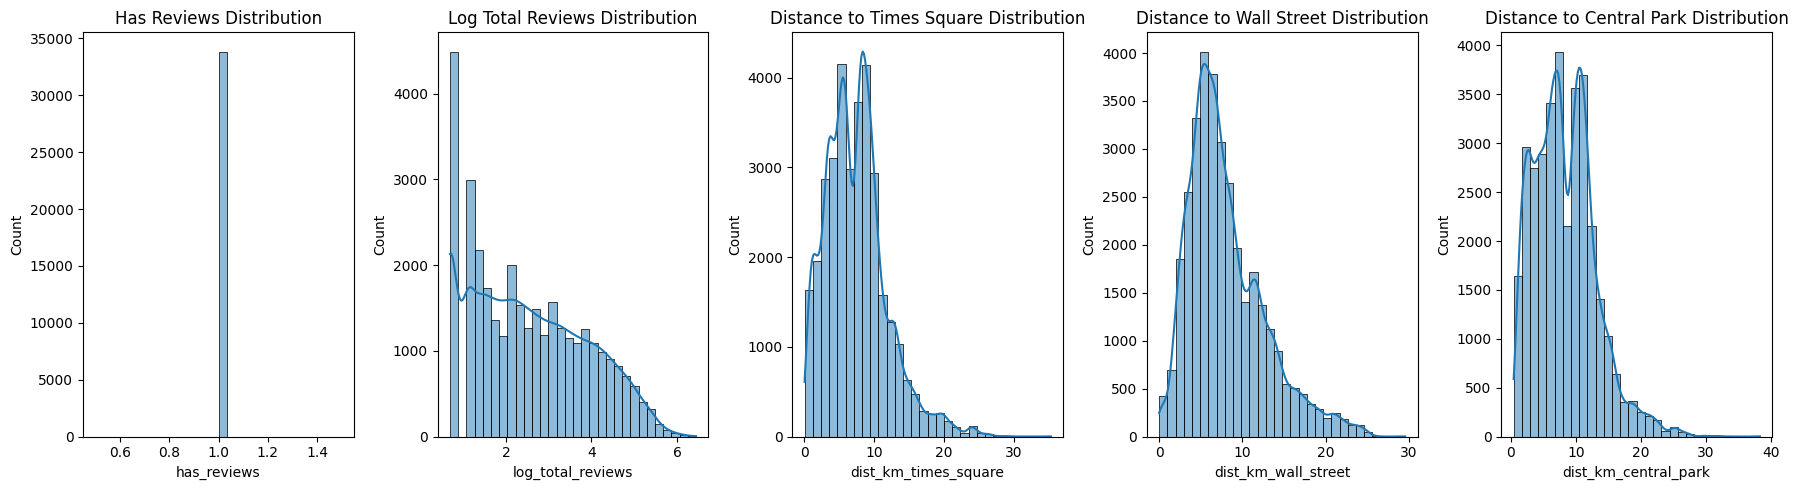

In [171]:
#----------------------------------------
# Step 4: Visualize the New Features
#----------------------------------------

# Plot distributions of the new features to check if they make sense
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
sns.histplot(df['has_reviews'], bins=30, ax=axes[0], kde=True).set_title('Has Reviews Distribution')
sns.histplot(df['log_total_reviews'], bins=30, ax=axes[1], kde=True).set_title('Log Total Reviews Distribution')
sns.histplot(df['dist_km_times_square'], bins=30, ax=axes[2], kde=True).set_title('Distance to Times Square Distribution')
sns.histplot(df['dist_km_wall_street'], bins=30, ax=axes[3], kde=True).set_title('Distance to Wall Street Distribution')
sns.histplot(df['dist_km_central_park'], bins=30, ax=axes[4], kde=True).set_title('Distance to Central Park Distribution')
plt.tight_layout()
plt.show()
# 🧠 Why this matters:
# - The visualizations help us understand the distribution of our engineered features.
# - If the distributions are skewed or have outliers, it might affect model performance.
# - It's a good practice to visually inspect engineered features before using them in modelling.

In [172]:
df=df.drop(columns=["total_reviews"], errors="ignore")
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews,log_total_reviews,dist_km_times_square,dist_km_wall_street,dist_km_central_park
0,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,1,3.828641,0.508366,5.698776,3.394152
1,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1,5.602119,8.387034,4.768098,10.696471
2,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,1,2.302585,5.701496,11.647582,2.701110
3,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129,1,4.317488,1.449704,5.442729,3.796468
4,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,0.40,1,0,1,3.912023,8.290747,4.963633,10.525438


In [173]:
#-------------------------------------------------------------
# Step 5: Number of unique values on categorical variables and list the name of unique values of the ones with less than 10 unique values
#-------------------------------------------------------------
# lets check for the number of unique values in each categorical column
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_values = df[col].nunique()
    print(f"\nColumn '{col}' has {unique_values} unique values.")
    if unique_values < 10:
        print(f"Unique values: {df[col].unique()}")


Column 'neighbourhood_group' has 5 unique values.
Unique values: ['Manhattan' 'Brooklyn' 'Queens' 'Staten Island' 'Bronx']

Column 'neighbourhood' has 216 unique values.

Column 'room_type' has 3 unique values.
Unique values: ['Entire home/apt' 'Private room' 'Shared room']


In [174]:

# --------------------------------------------------
# Step 6: Aggregate geo coordinates per (group, neighbourhood)
# --------------------------------------------------
neighbourhood_geo = (
    df.groupby(["neighbourhood_group", "neighbourhood"])
      .agg(
          latitude=("latitude", "median"),
          longitude=("longitude", "median")
      )
      .reset_index()
)

# --------------------------------------------------
# Step 7: Create hierarchical key
# --------------------------------------------------
neighbourhood_geo["neighbourhood_key"] = (
    neighbourhood_geo["neighbourhood_group"] + "_" +
    neighbourhood_geo["neighbourhood"]
)

# --------------------------------------------------
# Step 8: Build lookup dictionary for inference
# --------------------------------------------------
geo_lookup = (
    neighbourhood_geo
    .set_index("neighbourhood_key")[["latitude", "longitude"]]
    .to_dict(orient="index")
)

# --------------------------------------------------
# Step 9: Persist lookup (for main.py inference)
# --------------------------------------------------
with open("../configs/neighbourhood_geo.json", "w") as f:
    json.dump(geo_lookup, f, indent=2)


In [175]:
#---------------------------------------------------------------------
# Step 9: Combine neighbourhood and neighbourhood_group into a new engineered feature: neighbourhood_hierarchical
#---------------------------------------------------------------------
df['neighbourhoods'] = df['neighbourhood_group'] + "_" + df['neighbourhood']

df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews,log_total_reviews,dist_km_times_square,dist_km_wall_street,dist_km_central_park,neighbourhoods
0,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,1,3.828641,0.508366,5.698776,3.394152,Manhattan_Midtown
1,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1,5.602119,8.387034,4.768098,10.696471,Brooklyn_Clinton Hill
2,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,1,2.302585,5.701496,11.647582,2.701110,Manhattan_East Harlem
3,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129,1,4.317488,1.449704,5.442729,3.796468,Manhattan_Murray Hill
4,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,0.40,1,0,1,3.912023,8.290747,4.963633,10.525438,Brooklyn_Bedford-Stuyvesant


In [176]:

# Using sorted() ensures the dropdown list in your API is alphabetical
unique_neighbourhoods = sorted(df['neighbourhoods'].unique().tolist())

# 2. Save the deduplicated list to your config folder
high_cardinality_categorical_path = '../configs/neighbourhoods.json'
with open(high_cardinality_categorical_path, 'w') as f:
    json.dump(unique_neighbourhoods, f, indent=2)

print(f"Saved {len(unique_neighbourhoods)} unique locations.")


Saved 216 unique locations.


In [177]:

# -------------------------------------------------------------
# Step 10: Lets Label_encode categorical variables with less than 10 unique values neighbourhood_group and room_type, then one hot the neighborhood
# -------------------------------------------------------------
# Label encoding for 'neighbourhood_group' and 'room_type' columns
label_enc_cols = ['room_type', 'neighbourhood_group']
ordinal_encoder = OrdinalEncoder()
for col in label_enc_cols:
    df[col] = ordinal_encoder.fit_transform(df[col].values.reshape(-1, 1)).flatten()


# One hot encoding using onehotencoder for 'neighbourhood' column
onehot_encoder = OneHotEncoder(handle_unknown='ignore', drop='first')
neighbourhood_encoded = onehot_encoder.fit_transform(df[['neighbourhoods']]).toarray()
neighbourhood_encoded_df = pd.DataFrame(neighbourhood_encoded, columns=onehot_encoder.get_feature_names_out(['neighbourhoods']))
df = pd.concat([df, neighbourhood_encoded_df], axis=1)
df.drop('neighbourhood', axis=1, inplace=True)
df.drop('neighbourhoods', axis=1, inplace=True)
df.head()


,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,...,neighbourhoods_Staten Island_Shore Acres,neighbourhoods_Staten Island_Silver Lake,neighbourhoods_Staten Island_South Beach,neighbourhoods_Staten Island_St. George,neighbourhoods_Staten Island_Stapleton,neighbourhoods_Staten Island_Todt Hill,neighbourhoods_Staten Island_Tompkinsville,neighbourhoods_Staten Island_Tottenville,neighbourhoods_Staten Island_West Brighton,neighbourhoods_Staten Island_Westerleigh
0,2.0,40.75362,-73.98377,0.0,225,1,45,0.38,2,355,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,40.68514,-73.95976,0.0,89,1,270,4.64,1,194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,40.79851,-73.94399,0.0,80,10,9,0.10,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.0,40.74767,-73.97500,0.0,200,3,74,0.59,1,129,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,40.68688,-73.95596,1.0,60,45,49,0.40,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [178]:
df=df.drop(columns=["price"], errors="ignore")
df.shape

(33842, 229)

In [179]:
# Lets store the feature names and types for later use in the API schema
feature_names = df.dtypes.apply(lambda x: x.type).to_dict()
meta_path= '../configs/feature_metadata.json'
with open(meta_path, 'w') as f:
    json.dump({k: str(v) for k, v in feature_names.items() if k != 'price'}, f, indent=2)
# ---

In [180]:
# 💾 Save Final Engineered Features (Human-Readable CSV)

df.to_csv("../data/processed/AB_NYC_2019_feature_engineered.csv", index=False)
print("✅ Feature engineered data saved to '../data/processed/AB_NYC_2019_feature_engineered.csv'")

✅ Feature engineered data saved to '../data/processed/AB_NYC_2019_feature_engineered.csv'
